In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Dropout, Conv2D
from tensorflow.keras import optimizers

In [5]:


# Match contours to license plate or character template
def find_contours(dimensions, img) :

    # Find all contours in the image
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Retrieve potential dimensions
    lower_width = dimensions[0]
    upper_width = dimensions[1]
    lower_height = dimensions[2]
    upper_height = dimensions[3]
    
    # Check largest 5 or  15 contours for license plate or character respectively
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:15]
    
    ii = cv2.imread('contour.jpg')
    
    x_cntr_list = []
    target_contours = []
    img_res = []
    for cntr in cntrs :
        #detects contour in binary image and returns the coordinates of rectangle enclosing it
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        
        #checking the dimensions of the contour to filter out the characters by contour's size
        if intWidth > lower_width and intWidth < upper_width and intHeight > lower_height and intHeight < upper_height :
            x_cntr_list.append(intX) #stores the x coordinate of the character's contour, to used later for indexing the contours

            char_copy = np.zeros((44,24))
            #extracting each character using the enclosing rectangle's coordinates.
            char = img[intY:intY+intHeight, intX:intX+intWidth]
            char = cv2.resize(char, (20, 40))
            
            cv2.rectangle(ii, (intX,intY), (intWidth+intX, intY+intHeight), (50,21,200), 2)
            plt.imshow(ii, cmap='gray')

#             Make result formatted for classification: invert colors
            char = cv2.subtract(255, char)

            # Resize the image to 24x44 with black border
            char_copy[2:42, 2:22] = char
            char_copy[0:2, :] = 0
            char_copy[:, 0:2] = 0
            char_copy[42:44, :] = 0
            char_copy[:, 22:24] = 0

            img_res.append(char_copy) #List that stores the character's binary image (unsorted)
            
    #Return characters on ascending order with respect to the x-coordinate (most-left character first)
            
    plt.show()
    #arbitrary function that stores sorted list of character indeces
    indices = sorted(range(len(x_cntr_list)), key=lambda k: x_cntr_list[k])
    img_res_copy = []
    for idx in indices:
        img_res_copy.append(img_res[idx])# stores character images according to their index
    img_res = np.array(img_res_copy)

    return img_res

In [6]:
# Find characters in the resulting images
def segment_characters(image) :

    # Preprocess cropped license plate image
    img_lp = cv2.resize(image, (333, 75))
    img_gray_lp = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY)
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    img_binary_lp = cv2.erode(img_binary_lp, (3,3))
    img_binary_lp = cv2.dilate(img_binary_lp, (3,3))

    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]

    # Make borders white
    img_binary_lp[0:3,:] = 255
    img_binary_lp[:,0:3] = 255
    img_binary_lp[72:75,:] = 255
    img_binary_lp[:,330:333] = 255

    # Estimations of character contours sizes of cropped license plates
    dimensions = [LP_WIDTH/6,
                       LP_WIDTH/2,
                       LP_HEIGHT/10,
                       2*LP_HEIGHT/3]
    plt.imshow(img_binary_lp, cmap='gray')
    plt.show()
    cv2.imwrite('contour.jpg',img_binary_lp)

    # Get contours within cropped license plate
    char_list = find_contours(dimensions, img_binary_lp)

    return char_list

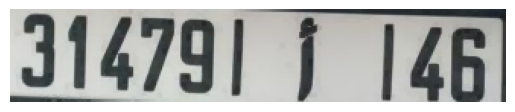

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(r"C:\Users\DELL\Downloads\license_plate_1.jpg")

if image is None:
    print("Erreur : L'image n'a pas pu être chargée. Vérifiez le chemin.")
else:
    # Taille de la structuring element (kernel)
    kernel_size = (3, 3)

    # Création du noyau
    kernel = np.ones(kernel_size, np.uint8)

    # Dilater l'image
    dilated_image = cv2.erode(image, kernel, iterations=1)

    # Afficher l'image dilatée avec Matplotlib
    plt.imshow(cv2.cvtColor(dilated_image, cv2.COLOR_BGR2RGB))

    plt.axis('off')
    plt.show()


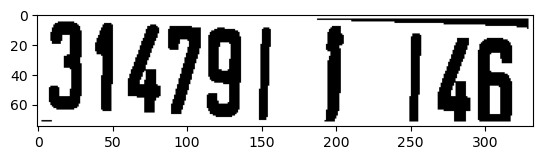

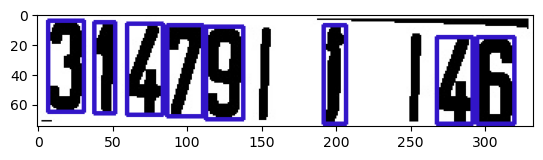

8

In [14]:
img = dilated_image
char = segment_characters(img)
char.shape[0]

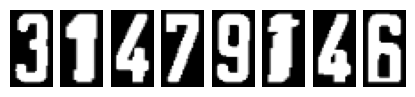

In [80]:
for i in range(char.shape[0]):
    plt.subplot(1, 10, i+1)
    plt.imshow(char[i], cmap='gray')
    plt.axis('off')

### Model for characters

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255, width_shift_range=0.1, height_shift_range=0.1)
train_generator = train_datagen.flow_from_directory(
        'data/train',  # this is the target directory
        target_size=(28,28),  # all images will be resized to 28x28
        batch_size=1,
        class_mode='categorical')

validation_generator = train_datagen.flow_from_directory(
        'data/val',  # this is the target directory
        target_size=(28,28),  # all images will be resized to 28x28        batch_size=1,
        class_mode='categorical')

Found 864 images belonging to 36 classes.
Found 216 images belonging to 36 classes.


In [37]:
model = Sequential()
model.add(Conv2D(32, (24,24), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(36, activation='softmax'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 32)          │          55,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 36)                  │           4,644 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 862,916 (3.29 MB)

 Trainable params: 862,916 (3.29 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.summary

<bound method Model.summary of <Sequential name=sequential_2, built=True>>

In [22]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    metrics=['accuracy']
)

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint

batch_size = 1

# Define the checkpoint callback to save the model weights after each epoch
checkpoint_callback = ModelCheckpoint(
    'model_last_weights.weights.h5',  # Save the model weights
    save_best_only=True,              # Save only the best model based on monitored metric
    save_weights_only=True,           # Save only weights, not the full model
    monitor='val_loss',               # Monitor validation loss
    mode='min',                       # Minimize validation loss
    verbose=1                         # Display save messages
)

# Train the model and store the history
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=80,
    callbacks=[checkpoint_callback]
)

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/80
863/864 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1798 - loss: 3.1174

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from inf to 1.48930, saving model to model_last_weights.weights.h5
864/864 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.1802 - loss: 3.1159 - val_accuracy: 0.5926 - val_loss: 1.4893
Epoch 2/80


C:\Users\DELL\anaconda3\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)



Epoch 2: val_loss improved from 1.48930 to 1.48156, saving model to model_last_weights.weights.h5
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6065 - val_loss: 1.4816
Epoch 3/80
862/864 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6555 - loss: 1.1181
Epoch 3: val_loss improved from 1.48156 to 0.63310, saving model to model_last_weights.weights.h5
864/864 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.6557 - loss: 1.1174 - val_accuracy: 0.8056 - val_loss: 0.6331
Epoch 4/80

Epoch 4: val_loss did not improve from 0.63310
864/864 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8194 - val_loss: 0.7223
Epoch 5/80
863/864 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8241 - loss: 0.5684
Epoch 5: val_loss improved from 0.63310 to 0.46386, saving model to model_last_weights.weights.h5
864/864 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8241 - loss: 0.5683 - val_accuracy: 0.8519

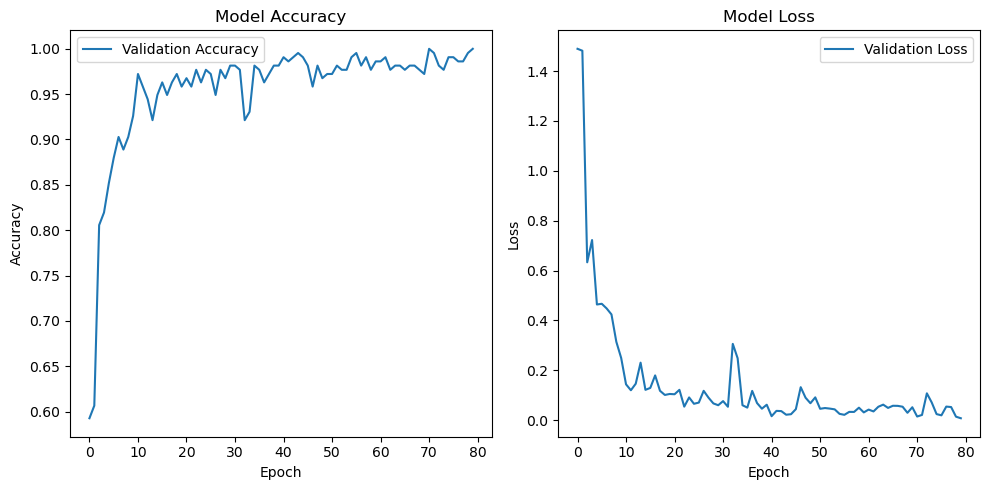

In [30]:
# Plot accuracy
plt.figure(figsize=(10, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Loss
plt.subplot(1, 2, 2)

plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
model.save("model_last_complete.keras")  

NameError: name 'model' is not defined

In [38]:
model.save_weights('model_last_weights.weights.h5')


NameError: name 'model' is not defined

In [50]:
# Function to fix dimensions of grayscale images
def fix_dimension(img): 
    new_img = np.zeros((28, 28, 3))
    for i in range(3):
        new_img[:, :, i] = img
    return new_img

# Function to predict license plate characters
def show_results(model, char_images, characters_list):
    # Create dictionary to map indices to characters
    dic = {i: c for i, c in enumerate(characters_list)}

    output = []  # List to store detected characters
    for i, ch in enumerate(char_images):
        # Preprocess character image
        img_ = cv2.resize(ch, (28, 28))  # Resize to (28, 28)
        img = fix_dimension(img_)        # Convert to (28, 28, 3)
        img = img.reshape(1, 28, 28, 3)  # Prepare for model input

        # Predict the character
        y_ = np.argmax(model.predict(img), axis=-1)[0]
        character = dic[y_]
        output.append(character)  # Store result

    # Combine characters into a single string
    plate_number = ''.join(output)
    return plate_number

In [40]:
# Step 1: Load the Trained Model
model_path = "model_last_complete.keras"  # Replace with the path to your model
model = load_model(model_path)

In [41]:
# Step 2: Define Possible Characters
characters_list = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [84]:
# Step 3: Prepare Sample Character Images
# Replace this with actual images of segmented characters
char_images = char

Character Images:


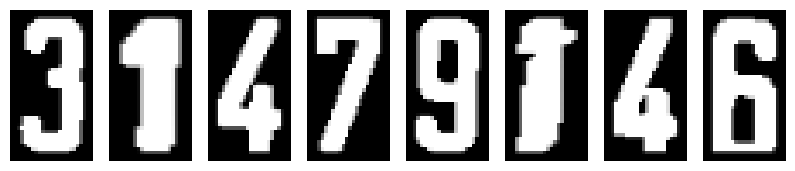

In [86]:
# Step 4: Visualize the Character Images
print("Character Images:")
plt.figure(figsize=(10, 2))
for i, img in enumerate(char_images):
    plt.subplot(1, len(char_images), i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

In [88]:
# Step 5: Predict the License Plate Number
plate_number = show_results(model, char_images, characters_list)
print(f"Detected License Plate Number: {plate_number}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Detected License Plate Number: 31478J46
